In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load CSV
data = pd.read_csv("drug200.csv")

# Encode categorical columns
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop("Drug", axis=1)
y = data["Drug"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree
model = DecisionTreeClassifier(criterion="entropy", max_depth=4)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


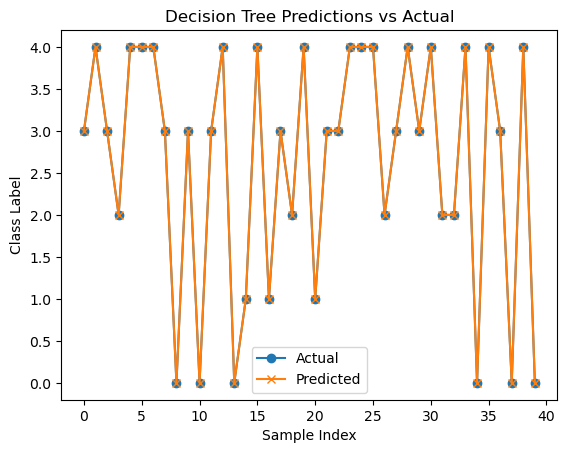

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numeric index for plotting
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

plt.figure()
plt.plot(y_test_np, label="Actual", marker='o')
plt.plot(y_pred_np, label="Predicted", marker='x')
plt.title("Decision Tree Predictions vs Actual")
plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.legend()
plt.show()
